# K-Means Clustering

In [69]:
import pandas as pd
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore") 

In [70]:
data = pd.read_excel('FinalStock.xlsx')
data.head()

,Symbol,Company Name,Market cap,Beta,P/E,Price,Volume,Annual Return
0,NESTLEIND.NS,Nestlé India Limited,2419889446450,0.042,79.86,2509.85,2028038,0.3844
1,IDFCFIRSTB.NS,IDFC First Bank Limited,546719880000,0.903,18.37,77.25,97310059,0.3722
2,KARURVYSYA.NS,The Karur Vysya Bank Limited,155266778900,0.859,9.92,194.05,3173706,0.8161
3,IBREALEST.NS,Indiabulls Real Estate Limited,79886813692,1.165,-6.92,126.80,13184531,1.3957
4,GMRP&UI.NS,GMR Power And Urban Infra Limited,38780913472,0.571,-9.62,64.25,6149127,1.6288


In [71]:
features = ['Market cap','Beta','P/E']
X = data[features]

In [72]:
scaler = StandardScaler()
scaled_features = scaler.fit_transform(X)
scaled_features

array([[ 2.16912574, -1.14695224,  0.40205321],
       [ 0.31691284,  0.62623433, -0.18133436],
       [-0.07016076,  0.53561853, -0.2615039 ],
       ...,
       [-0.2177767 , -0.35406393, -0.3601741 ],
       [-0.2178992 , -1.39408625,  0.22786235],
       [-0.21845641, -0.27374538, -0.5911952 ]])

In [73]:
inertia = []
for n in range(1, 16):
    kmeans = KMeans(n_clusters=n)
    kmeans.fit(scaled_features)
    inertia.append(kmeans.inertia_)

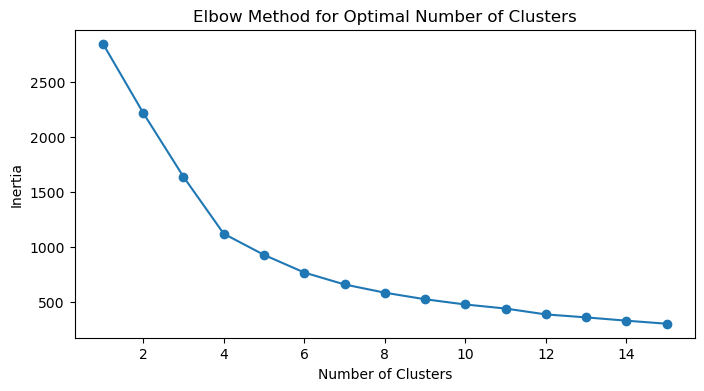

In [74]:
plt.figure(figsize=(8, 4))
plt.plot(range(1, 16), inertia, marker='o')
plt.xlabel('Number of Clusters')
plt.ylabel('Inertia')
plt.title('Elbow Method for Optimal Number of Clusters')
plt.show()

In [75]:
optimal_clusters = 5 
kmeans = KMeans(n_clusters=optimal_clusters,random_state=42)
data['Cluster'] = kmeans.fit_predict(scaled_features)
data.head()

,Symbol,Company Name,Market cap,Beta,P/E,Price,Volume,Annual Return,Cluster
0,NESTLEIND.NS,Nestlé India Limited,2419889446450,0.042,79.86,2509.85,2028038,0.3844,3
1,IDFCFIRSTB.NS,IDFC First Bank Limited,546719880000,0.903,18.37,77.25,97310059,0.3722,1
2,KARURVYSYA.NS,The Karur Vysya Bank Limited,155266778900,0.859,9.92,194.05,3173706,0.8161,1
3,IBREALEST.NS,Indiabulls Real Estate Limited,79886813692,1.165,-6.92,126.80,13184531,1.3957,1
4,GMRP&UI.NS,GMR Power And Urban Infra Limited,38780913472,0.571,-9.62,64.25,6149127,1.6288,0


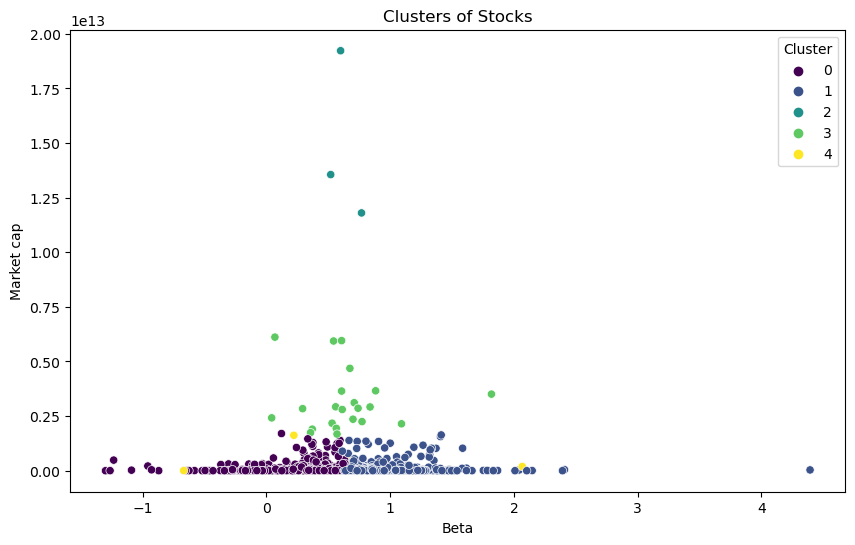

In [76]:
plt.figure(figsize=(10, 6))
sns.scatterplot(x='Beta', y='Market cap', hue='Cluster', data=data, palette='viridis')
plt.title('Clusters of Stocks')
plt.xlabel('Beta')
plt.ylabel('Market cap')
plt.show()

In [77]:
cluster_distribution = data['Cluster'].value_counts()
cluster_distribution

Cluster
0    482
1    433
3     22
4     10
2      3
Name: count, dtype: int64

In [81]:
clustered_file_path = 'clusteredFinal22.csv'
data.to_csv(clustered_file_path, index=False)